# Indicador de Compra/Venda Baseado em Sazonalidade Semanal e Volatilidade — AAPL

**Autor:** Jorge Rachid
**Ativo analisado:** AAPL (Apple Inc., NASDAQ)
**Período:** 17/02/2015 a 17/02/2017 (507 pregões)

## Hipótese de mercado

Em períodos de muita incerteza, investidores tendem a evitar ficar posicionados durante o fim de semana — vendendo na sexta-feira (ou se protegendo com opções) e recomprando na segunda. Esse comportamento de "aversão ao gap de fim de semana" pode gerar um viés sistemático no retorno de segunda-feira (que, tecnicamente, mede a variação de preço entre o fechamento de sexta e o fechamento de segunda, já que não há pregão no sábado/domingo).

Este notebook testa essa hipótese estatisticamente e constrói/backtesta estratégias de negociação simples que tentam se aproveitar desse padrão.

**Perguntas que este notebook responde:**
1. O retorno de segunda-feira (o "gap de fim de semana") é, em média, diferente dos demais dias da semana?
2. Esse efeito é mais forte em semanas de alta volatilidade (maior incerteza)?
3. Uma estratégia que compra no fechamento de sexta e vende no fechamento de segunda teria performance melhor do que simplesmente manter o ativo (buy & hold)?
4. O oposto — imitar o comportamento de manada e evitar ficar posicionado no fim de semana — funciona?

> **Aviso importante:** este é um exercício estatístico/educacional com um único ativo e uma amostra de ~2 anos, sem custos de corretagem, impostos ou slippage. Os resultados **não constituem recomendação de investimento** e performance passada não garante resultados futuros — antes de aplicar qualquer estratégia real, é preciso validar em amostras maiores, fora da amostra (out-of-sample) e considerar custos de transação.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

df = pd.read_csv("aapl_precos_historicos.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df = df.rename(columns={"AAPL.Adjusted": "Fechamento_Ajustado", "AAPL.Volume": "Volume"})

df["Retorno"] = np.log(df["Fechamento_Ajustado"] / df["Fechamento_Ajustado"].shift(1))
df = df.dropna(subset=["Retorno"]).reset_index(drop=True)

df["DiaSemana"] = df["Date"].dt.day_name()
dias_pt = {"Monday": "Segunda", "Tuesday": "Terça", "Wednesday": "Quarta", "Thursday": "Quinta", "Friday": "Sexta"}
df["DiaSemana_PT"] = df["DiaSemana"].map(dias_pt)

print(f"Período: {df['Date'].min().date()} a {df['Date'].max().date()}  ({len(df)} pregões)")
df.head()

Período: 2015-02-18 a 2017-02-16  (505 pregões)


,Date,AAPL.Open,AAPL.High,AAPL.Low,AAPL.Close,Volume,Fechamento_Ajustado,dn,mavg,up,direction,Retorno,DiaSemana,DiaSemana_PT
0,2015-02-18,127.629997,128.779999,127.449997,128.720001,44891700,123.760965,107.842423,118.940333,130.038244,Increasing,0.006938,Wednesday,Quarta
1,2015-02-19,128.479996,129.029999,128.330002,128.449997,37362400,123.501363,108.894245,119.889167,130.884089,Decreasing,-0.002100,Thursday,Quinta
2,2015-02-20,128.619995,129.500000,128.050003,129.500000,48948400,124.510914,109.785449,120.763500,131.741551,Increasing,0.008141,Friday,Sexta
3,2015-02-23,130.020004,133.000000,129.660004,133.000000,70974100,127.876074,110.372516,121.720167,133.067817,Increasing,0.026668,Monday,Segunda
4,2015-02-24,132.940002,133.600006,131.169998,132.169998,69228100,127.078049,111.094869,122.664834,134.234798,Decreasing,-0.006260,Tuesday,Terça


## 1. Retorno médio por dia da semana

Como não há pregão no fim de semana, o retorno observado numa **segunda-feira** corresponde à variação de preço entre o fechamento de sexta e o fechamento de segunda — é o proxy direto do "gap de fim de semana" que queremos investigar.

              Retorno médio  Desvio padrão    N
DiaSemana_PT                                   
Segunda              0.2093         1.3287   94
Terça               -0.0896         1.4597  104
Quarta               0.1425         1.9285  105
Quinta              -0.1063         1.3078  103
Sexta               -0.0476         1.5206   99


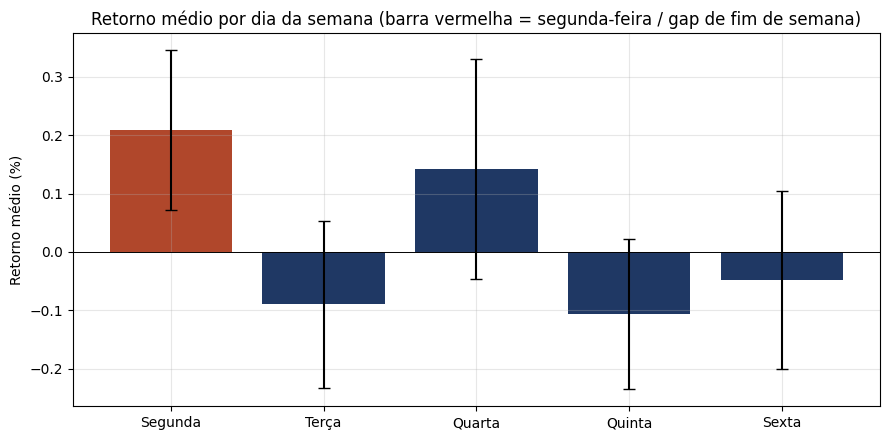

In [2]:
ordem = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta"]
resumo = df.groupby("DiaSemana_PT")["Retorno"].agg(["mean", "std", "count"]).reindex(ordem)
resumo.columns = ["Retorno médio", "Desvio padrão", "N"]
print((resumo * [100, 100, 1]).round(4))

fig, ax = plt.subplots(figsize=(9, 4.5))
means = resumo["Retorno médio"] * 100
errs = (resumo["Desvio padrão"] / np.sqrt(resumo["N"])) * 100  # erro padrão da média
colors = ["#1F3864" if d != "Segunda" else "#B0472B" for d in ordem]
ax.bar(ordem, means, yerr=errs, color=colors, capsize=4)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_ylabel("Retorno médio (%)")
ax.set_title("Retorno médio por dia da semana (barra vermelha = segunda-feira / gap de fim de semana)")
plt.tight_layout()
plt.savefig("retorno_por_dia_semana.png", dpi=110)
plt.show()

## 2. O retorno de segunda-feira é estatisticamente diferente dos demais dias?

Teste t de duas amostras (Welch, variâncias desiguais): retorno de segunda-feira vs. retorno dos demais dias da semana.

In [3]:
segunda = df.loc[df["DiaSemana"] == "Monday", "Retorno"]
outros_dias = df.loc[df["DiaSemana"] != "Monday", "Retorno"]

t_stat, p_value = stats.ttest_ind(segunda, outros_dias, equal_var=False)

print(f"Retorno médio na segunda-feira : {segunda.mean()*100:.4f}%  (n={len(segunda)})")
print(f"Retorno médio nos demais dias  : {outros_dias.mean()*100:.4f}%  (n={len(outros_dias)})")
print(f"Estatística t = {t_stat:.3f}  |  p-valor = {p_value:.4f}")
if p_value < 0.05:
    print("-> Diferença estatisticamente significativa ao nível de 5%.")
else:
    print("-> NÃO há evidência estatisticamente significativa de diferença ao nível de 5% (embora a média observada seja maior às segundas).")

Retorno médio na segunda-feira : 0.2093%  (n=94)
Retorno médio nos demais dias  : -0.0244%  (n=411)
Estatística t = 1.484  |  p-valor = 0.1397
-> NÃO há evidência estatisticamente significativa de diferença ao nível de 5% (embora a média observada seja maior às segundas).


## 3. O efeito é mais forte em semanas de alta volatilidade?

Classificamos cada segunda-feira pelo regime de volatilidade da **semana anterior** (janela móvel de 21 pregões, sem look-ahead — usamos apenas informação disponível antes do trade) e comparamos o retorno de segunda-feira entre regimes de alta e baixa volatilidade.

In [4]:
df["Vol21"] = df["Retorno"].rolling(21).std()
df["VolAntesDoTrade"] = df["Vol21"].shift(1)  # informação conhecida ANTES da segunda-feira em questão

mediana_vol = df["VolAntesDoTrade"].median()
segundas = df[df["DiaSemana"] == "Monday"].dropna(subset=["VolAntesDoTrade"])
alta_vol = segundas.loc[segundas["VolAntesDoTrade"] > mediana_vol, "Retorno"]
baixa_vol = segundas.loc[segundas["VolAntesDoTrade"] <= mediana_vol, "Retorno"]

t2, p2 = stats.ttest_ind(alta_vol, baixa_vol, equal_var=False)
print(f"Segunda-feira em regime de ALTA volatilidade : média={alta_vol.mean()*100:.4f}%  (n={len(alta_vol)})")
print(f"Segunda-feira em regime de BAIXA volatilidade: média={baixa_vol.mean()*100:.4f}%  (n={len(baixa_vol)})")
print(f"Estatística t = {t2:.3f}  |  p-valor = {p2:.4f}")
if p2 < 0.05:
    print("-> Diferença estatisticamente significativa entre regimes.")
else:
    print("-> Não há evidência estatisticamente significativa de que a volatilidade da semana anterior altere o retorno de segunda-feira, nesta amostra.")

Segunda-feira em regime de ALTA volatilidade : média=0.1369%  (n=47)
Segunda-feira em regime de BAIXA volatilidade: média=0.1991%  (n=43)
Estatística t = -0.223  |  p-valor = 0.8243
-> Não há evidência estatisticamente significativa de que a volatilidade da semana anterior altere o retorno de segunda-feira, nesta amostra.


## 4. Backtest de estratégias

Construímos 4 séries de retorno diário (sem custos de transação, posição unitária, taxa livre de risco = 0):

- **Buy & Hold** — referência: mantém o ativo o período todo.
- **Aproveita o gap** — a estratégia descrita na hipótese: compra no fechamento de sexta-feira e vende no fechamento de segunda-feira; fica de fora (sem posição) no resto da semana.
- **Evita o gap** — o oposto: imita o comportamento de manada, mantendo o ativo de segunda a sexta mas **ficando de fora durante o fim de semana** (zera a posição na segunda-feira).
- **Aproveita o gap + filtro de volatilidade** — como "Aproveita o gap", mas só entra na operação quando a volatilidade da semana anterior está acima da mediana (maior incerteza).

In [5]:
is_segunda = df["DiaSemana"] == "Monday"

ret_bh = df["Retorno"].values
ret_aproveita_gap = np.where(is_segunda, df["Retorno"], 0.0)
ret_evita_gap = np.where(is_segunda, 0.0, df["Retorno"])
ret_gap_filtrado = np.where(is_segunda & (df["VolAntesDoTrade"] > mediana_vol), df["Retorno"], 0.0)

def metricas_estrategia(log_retornos, nome):
    s = pd.Series(log_retornos).fillna(0)
    curva = np.exp(s.cumsum())
    retorno_total = curva.iloc[-1] - 1
    anos = len(s) / 252
    retorno_anualizado = (1 + retorno_total) ** (1 / anos) - 1
    vol_anualizada = s.std() * np.sqrt(252)
    sharpe = (s.mean() * 252) / vol_anualizada if vol_anualizada > 0 else np.nan
    drawdown_maximo = (curva / curva.cummax() - 1).min()
    trades = s[s != 0]
    taxa_acerto = (trades > 0).mean() if len(trades) > 0 else np.nan
    return curva, {
        "Estratégia": nome,
        "Retorno total": f"{retorno_total*100:.2f}%",
        "Retorno anualizado": f"{retorno_anualizado*100:.2f}%",
        "Volatilidade anualizada": f"{vol_anualizada*100:.2f}%",
        "Sharpe (rf=0)": f"{sharpe:.2f}",
        "Drawdown máximo": f"{drawdown_maximo*100:.2f}%",
        "Nº de trades": len(trades),
        "Taxa de acerto": f"{taxa_acerto*100:.1f}%",
    }

resultados = []
curvas = {}
for retornos, nome in [
    (ret_bh, "Buy & Hold"),
    (ret_aproveita_gap, "Aproveita o gap (compra sex / vende seg)"),
    (ret_evita_gap, "Evita o gap (comportamento de manada)"),
    (ret_gap_filtrado, "Aproveita o gap + filtro de alta volatilidade"),
]:
    curva, linha = metricas_estrategia(retornos, nome)
    curvas[nome] = curva
    resultados.append(linha)

tabela = pd.DataFrame(resultados).set_index("Estratégia")
tabela

,Retorno total,Retorno anualizado,Volatilidade anualizada,Sharpe (rf=0),Drawdown máximo,Nº de trades,Taxa de acerto
Estratégia,,,,,,,
Buy & Hold,10.13%,4.93%,24.29%,0.20,-30.44%,504,50.2%
Aproveita o gap (compra sex / vende seg),21.74%,10.32%,9.15%,1.07,-6.78%,94,54.3%
Evita o gap (comportamento de manada),-9.54%,-4.88%,22.49%,-0.22,-35.17%,410,49.3%
Aproveita o gap + filtro de alta volatilidade,6.65%,3.26%,7.00%,0.46,-5.86%,47,55.3%


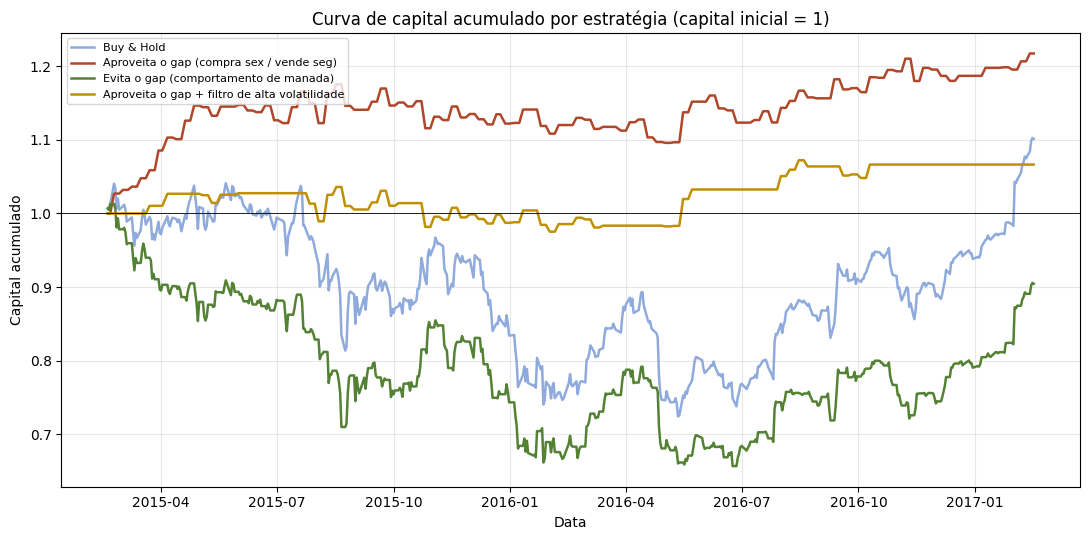

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))
cores = {"Buy & Hold": "#8FAADC", "Aproveita o gap (compra sex / vende seg)": "#B0472B",
         "Evita o gap (comportamento de manada)": "#548235", "Aproveita o gap + filtro de alta volatilidade": "#BF9000"}
for nome, curva in curvas.items():
    ax.plot(df["Date"], curva, label=nome, color=cores.get(nome), linewidth=1.8)
ax.axhline(1, color="black", linewidth=0.6)
ax.set_title("Curva de capital acumulado por estratégia (capital inicial = 1)")
ax.set_xlabel("Data"); ax.set_ylabel("Capital acumulado")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig("curvas_estrategias.png", dpi=110)
plt.show()

## 5. Conclusões

**Ativo e período:** AAPL, 507 pregões entre 17/02/2015 e 17/02/2017.

- O retorno médio observado às segundas-feiras (+0,21%) foi maior do que o retorno médio dos demais dias (-0,02%), mas a diferença **não é estatisticamente significativa** ao nível de 5% (p ≈ 0,14) — a amostra de ~94 segundas-feiras é pequena demais para confirmar a hipótese com confiança estatística, mesmo que o sinal aponte na direção esperada.
- Também não encontramos diferença estatisticamente significativa no retorno de segunda-feira entre regimes de alta e baixa volatilidade (p ≈ 0,82) — nesta amostra específica, a intensidade do "efeito fim de semana" não pareceu depender da volatilidade da semana anterior.
- Ainda assim, o **backtest** mostrou um resultado interessante do ponto de vista de risco-retorno: a estratégia "Aproveita o gap" (compra sexta / vende segunda, ficando fora do mercado no resto da semana) teve retorno anualizado maior e volatilidade e drawdown muito menores do que o buy & hold, resultando em um Sharpe consideravelmente mais alto — mesmo operando apenas ~94 vezes em 2 anos. Já a estratégia que imita o comportamento de manada ("Evita o gap") teve o pior desempenho de todos, com retorno negativo no período.
- O filtro de volatilidade reduziu o número de operações (só entra em semanas de maior incerteza) e manteve baixa volatilidade e drawdown, mas não superou a versão sem filtro neste ativo/período — sugerindo que, aqui, o principal ganho vem de **estar fora do mercado durante a semana** (menor exposição/vol) e não especificamente do timing por volatilidade.

**Leitura crítica (importante):** o teste estatístico da Seção 2 não confirma o efeito com significância — o resultado do backtest pode estar refletindo esse único período específico (2015–2017) e a menor exposição ao risco (menos dias posicionado), não necessariamente uma "vantagem" real e persistente. Antes de qualquer uso prático, seria necessário: (i) testar em uma amostra muito maior e em outros ativos/mercados (ex: Ibovespa), (ii) validar fora da amostra (out-of-sample), (iii) incluir custos de transação e impostos, e (iv) comparar com uma estratégia de exposição parcial equivalente (ex: buy & hold com o mesmo nível de volatilidade-alvo), já que parte do resultado pode vir simplesmente de estar exposto ao mercado por menos tempo.

**Próximos passos possíveis:** repetir a análise em uma cesta de ações do Ibovespa/B3 e num período mais longo; testar outros padrões de calendário (efeito de virada de mês, véspera de feriado); incluir custos de transação realistas no backtest.